# Cafe Sales Analysis — Insight & Reporting

This notebook summarizes findings from the data cleaning, EDA, and feature engineering processes into actionable business insights and recommendations.

**Important methodological notes:**
- Rows with empty `Item` were recovered using a unique price mapping per item (see notebook 1), not directly deleted.
- Duplicate checks include `Transaction ID`; transactions with identical attributes but different IDs are considered legitimate transactions that coincidentally occurred at the same time, not data errors.
- The `Spending Category` uses fixed limits (not percentiles); see specific notes in the relevant section.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cafe_sales_featured.csv")
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day,Day of Week,Is Weekend,Spending Category,Effective Unit Price
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,8,Friday,False,Low,2.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,16,Tuesday,False,Medium,3.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,19,Wednesday,False,Low,1.0
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,2023,4,27,Thursday,False,Medium,5.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,11,Sunday,True,Low,2.0


In [7]:
from google.colab import files

uploaded = files.upload()

Saving cafe_sales_featured.csv to cafe_sales_featured.csv


In [9]:
total_transactions = len(df)
total_revenue = df['Total Spent'].sum()
avg_transaction_value = df['Total Spent'].mean()

# Item based on 3 metrics (according to notebook 2)
top_item_frequency = df['Item'].value_counts().idxmax()
top_item_quantity = df.groupby('Item')['Quantity'].sum().idxmax()
top_item_revenue = df.groupby('Item')['Total Spent'].sum().idxmax()

top_payment = df['Payment Method'].value_counts().idxmax()
top_payment_pct = df['Payment Method'].value_counts(normalize=True).max() * 100

top_location = df['Location'].value_counts().idxmax()
top_location_pct = df['Location'].value_counts(normalize=True).max() * 100

print("=== EXECUTIVE SUMMARY ===")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Transaction Value: {avg_transaction_value:,.2f}")
print(f"Top Item (by frequency): {top_item_frequency}")
print(f"Top Item (by quantity sold): {top_item_quantity}")
print(f"Top Item (by revenue): {top_item_revenue}")
print(f"Dominant Payment Method: {top_payment} ({top_payment_pct:.1f}%)")
print(f"Dominant Order Type: {top_location} ({top_location_pct:.1f}%)")

=== EXECUTIVE SUMMARY ===
Total Transactions: 9,035
Total Revenue: 79,816.00
Average Transaction Value: 8.83
Top Item (by frequency): Coffee
Top Item (by quantity sold): Coffee
Top Item (by revenue): Salad
Dominant Payment Method: Digital Wallet (54.7%)
Dominant Order Type: Takeaway (69.9%)


## Executive Summary

The final dataset includes **9,035 transactions** with a total revenue of **79,816.00** and an average transaction value of **8.83** per transaction.

The most striking finding from this summary: **the best-selling item varies depending on the metric used**. Coffee excels in transaction frequency (1,239 transactions) and sales volume (3,759 units), but **Salad is the highest revenue contributor** (18,190.00) despite its lower frequency (1,212 transactions). This indicates a gap between "popular products" and "most profitable products" — a pattern that will be further analyzed in the Item Analysis section.

From an operational perspective, **Digital Wallet** dominates payment methods (54.7%) and **Takeaway** dominates order types (69.9%) — both showing clear and consistent customer preference for convenience/speed of transactions.

In [10]:
top_by_frequency = df['Item'].value_counts().head(5)
top_by_quantity = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(5)
top_by_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(5)

print("=== Top 5 by Frequency ===")
print(top_by_frequency)
print("\n=== Top 5 by Quantity ===")
print(top_by_quantity)
print("\n=== Top 5 by Revenue ===")
print(top_by_revenue)

=== Top 5 by Frequency ===
Item
Coffee    1239
Salad     1212
Cookie    1144
Tea       1135
Juice     1120
Name: count, dtype: int64

=== Top 5 by Quantity ===
Item
Coffee    3759.0
Salad     3638.0
Tea       3424.0
Cookie    3416.0
Juice     3339.0
Name: Quantity, dtype: float64

=== Top 5 by Revenue ===
Item
Salad       18190.0
Sandwich    12996.0
Smoothie    12736.0
Juice       10017.0
Cake         9807.0
Name: Total Spent, dtype: float64


### Finding 1: Coffee dominates popularity, but Salad dominates profitability

**Evidence:**

| Item | Frequency | Quantity Sold | Revenue | Revenue per Transaction |
|---|---|---|---|---|
| Coffee | 1,239 (#1) | 3,759 (#1) | ~7,518 | 6.07 |
| Salad | 1,212 (#2) | 3,638 (#2) | 18,190 (#1) | **15.01** |
| Juice | 1,120 (#5) | 3,339 (#5) | 10,017 (#4) | 8.94 |
| Cookie | 1,144 (#3) | 3,416 (#4) | ~3,416 | **2.99 (lowest)** |

*(Coffee and Cookie revenue figures are calculated from quantity × unit price, as they were not in the original top-5 revenue)*

Coffee and Cookies are **high-frequency but low-value-per-unit products** (prices 2.0 and 1.0) — customers buy them often, but each transaction contributes little to revenue. Conversely, Salad (price 5.0/unit) generates **2.5x higher revenue per transaction** than Coffee (15.01 vs 6.07), even though it is ordered less frequently.

**Implication:** Coffee and Cookies serve as **traffic drivers** (attracting customers) but are not the main drivers of profitability. Bundling strategies — for example, offering Salad or other high-value items as an accompaniment when customers order Coffee — have the potential to increase average transaction value without sacrificing the already high visit frequency.

In [11]:
spending_dist = df['Spending Category'].value_counts()
spending_pct = df['Spending Category'].value_counts(normalize=True) * 100
spending_revenue = df.groupby('Spending Category')['Total Spent'].sum()
spending_revenue_pct = spending_revenue / spending_revenue.sum() * 100

print("Distribution of transaction counts:")
print(spending_pct)
print("\nContribution to revenue:")
print(spending_revenue_pct)

Distribution of transaction counts:
Spending Category
Low       62.357499
Medium    34.786940
High       2.855562
Name: proportion, dtype: float64

Contribution to revenue:
Spending Category
High       8.081086
Low       34.434199
Medium    57.484715
Name: Total Spent, dtype: float64


### Finding 2: Medium transactions contribute more than half of revenue, despite being a minority in terms of number

**Evidence:**

| Category | % Transactions | % Revenue | Revenue:Transaction Ratio |
|---|---|---|---|
| Low (< 10) | 62.36% | 34.43% | 0.55x |
| Medium (10–25) | 34.79% | **57.48%** | **1.65x** |
| High (≥ 25) | 2.86% | 8.08% | 2.82x |

**Low transactions dominate in number (62.36%) but only contribute one-third of revenue (34.43%)** — their contribution ratio is below 1, meaning they are "under-contributing" relative to their proportion. Conversely, **Medium is the most efficient group in aggregate**: with only 34.79% of transactions, it generates 57.48% of revenue — a contribution ratio of 1.65x its proportion.

**Methodological note:** The "High" category limit (≥25) coincides with the maximum possible transaction value in this dataset (5 units × Salad price, the most expensive item). Therefore, "High" here represents transactions at the peak of the price×quantity structure (2.86% of the data), not a broad range of large spending.

**Implication:** The biggest revenue opportunity is not in pursuing the High segment (which is structurally limited, only achievable through purchasing the most expensive items in maximum quantity), but rather in **encouraging customers in the Low segment (62.36% of the transaction base) to upgrade to Medium** — for example, through small incentives such as "add an item, get a Rp2,000 discount" on transactions below the Medium threshold. Since the Medium segment has proven to be the most efficient in generating revenue, increasing its proportion has the potential to have a greater revenue impact than other strategies.

In [12]:
payment_dist = df['Payment Method'].value_counts(normalize=True) * 100
location_dist = df['Location'].value_counts(normalize=True) * 100

payment_location_cross = pd.crosstab(df['Payment Method'], df['Location'], normalize='index') * 100

print(payment_dist)
print(location_dist)
print("\nDistribution of Location per Payment Method:")
print(payment_location_cross)

Payment Method
Digital Wallet    54.720531
Credit Card       22.678473
Cash              22.600996
Name: proportion, dtype: float64
Location
Takeaway    69.894853
In-Store    30.105147
Name: proportion, dtype: float64

Distribution of Location per Payment Method:
Location         In-Store   Takeaway
Payment Method                      
Cash            30.754163  69.245837
Credit Card     30.014641  69.985359
Digital Wallet  29.874595  70.125405


### Finding 3: Takeaway preference is consistent across all payment methods — no correlation

**Evidence:**

| Payment Method | % Transactions | % Takeaway (within this method) |
|---|---|---|
| Digital Wallet | 54.72% | 70.13% |
| Credit Card | 22.68% | 69.99% |
| Cash | 22.60% | 69.25% |

The proportion of Takeaway is **almost identical across all three payment methods** (69.25%–70.13%, a difference of less than 1 percentage point). This indicates that the Takeaway preference is **customer behavior independent of how they pay** — it's not a pattern like "Digital Wallet users prefer Takeaway" or similar.

**Implication:** Since there's no correlation between payment methods and order types, operational strategies to **optimize Takeaway** (packaging speed, order pickup efficiency) should be implemented **uniformly**, without needing to segment based on customer payment methods. Conversely, investment in **Digital Wallet** remains relevant not because of its relationship with Takeaway, but because this method already dominates more than half of transactions (54.72%) independently.

In [13]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sales_by_day = df.groupby('Day of Week')['Total Spent'].sum().reindex(day_order)
avg_by_weekend = df.groupby('Is Weekend')['Total Spent'].mean()

print(sales_by_day)
print(avg_by_weekend)

Day of Week
Monday       11347.5
Tuesday      11348.5
Wednesday    10790.5
Thursday     11701.0
Friday       11651.5
Saturday     11302.5
Sunday       11674.5
Name: Total Spent, dtype: float64
Is Weekend
False    8.832789
True     8.837308
Name: Total Spent, dtype: float64


### Finding 4: No strong weekly pattern — demand is relatively stable throughout the day and week

**Evidence:**

Daily revenue ranges from **10,790.50 (Wednesday, lowest)** to **11,701.00 (Thursday, highest)** — a difference of only about 8.4%, which is relatively small and does not show a sharp weekly pattern (e.g., no significant surge on weekends).

The average transaction value between weekdays (8.833) and weekends (8.837) is **almost identical**, with a difference of less than 0.05% — practically, it can be considered no difference.

**Implication:** Demand at this cafe appears to be **independent of specific days** — there are no noticeable "slow days" or "busy days" to be used as a basis for special strategies. This means:
1. Staff and stock allocation can be planned relatively evenly throughout the week, without major adjustments needed for weekends.
2. Time-based promotions (e.g., "weekend discount") are likely **not to provide significant additional demand boosts**, as the basic demand is already stable — promotion budgets would be more effectively allocated to other strategies (such as upsell Low→Medium in Finding 2) rather than segmented by time.

/tmp/ipykernel_648/2557840389.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_by_revenue.values, y=top_by_revenue.index, ax=axes[0,0], palette="viridis")
/tmp/ipykernel_648/2557840389.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_day.index, y=sales_by_day.values, ax=axes[1,0], palette="coolwarm")
/tmp/ipykernel_648/2557840389.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spending_dist.index, y=spending_dist.values, ax=axes[1,1], palette="mako")


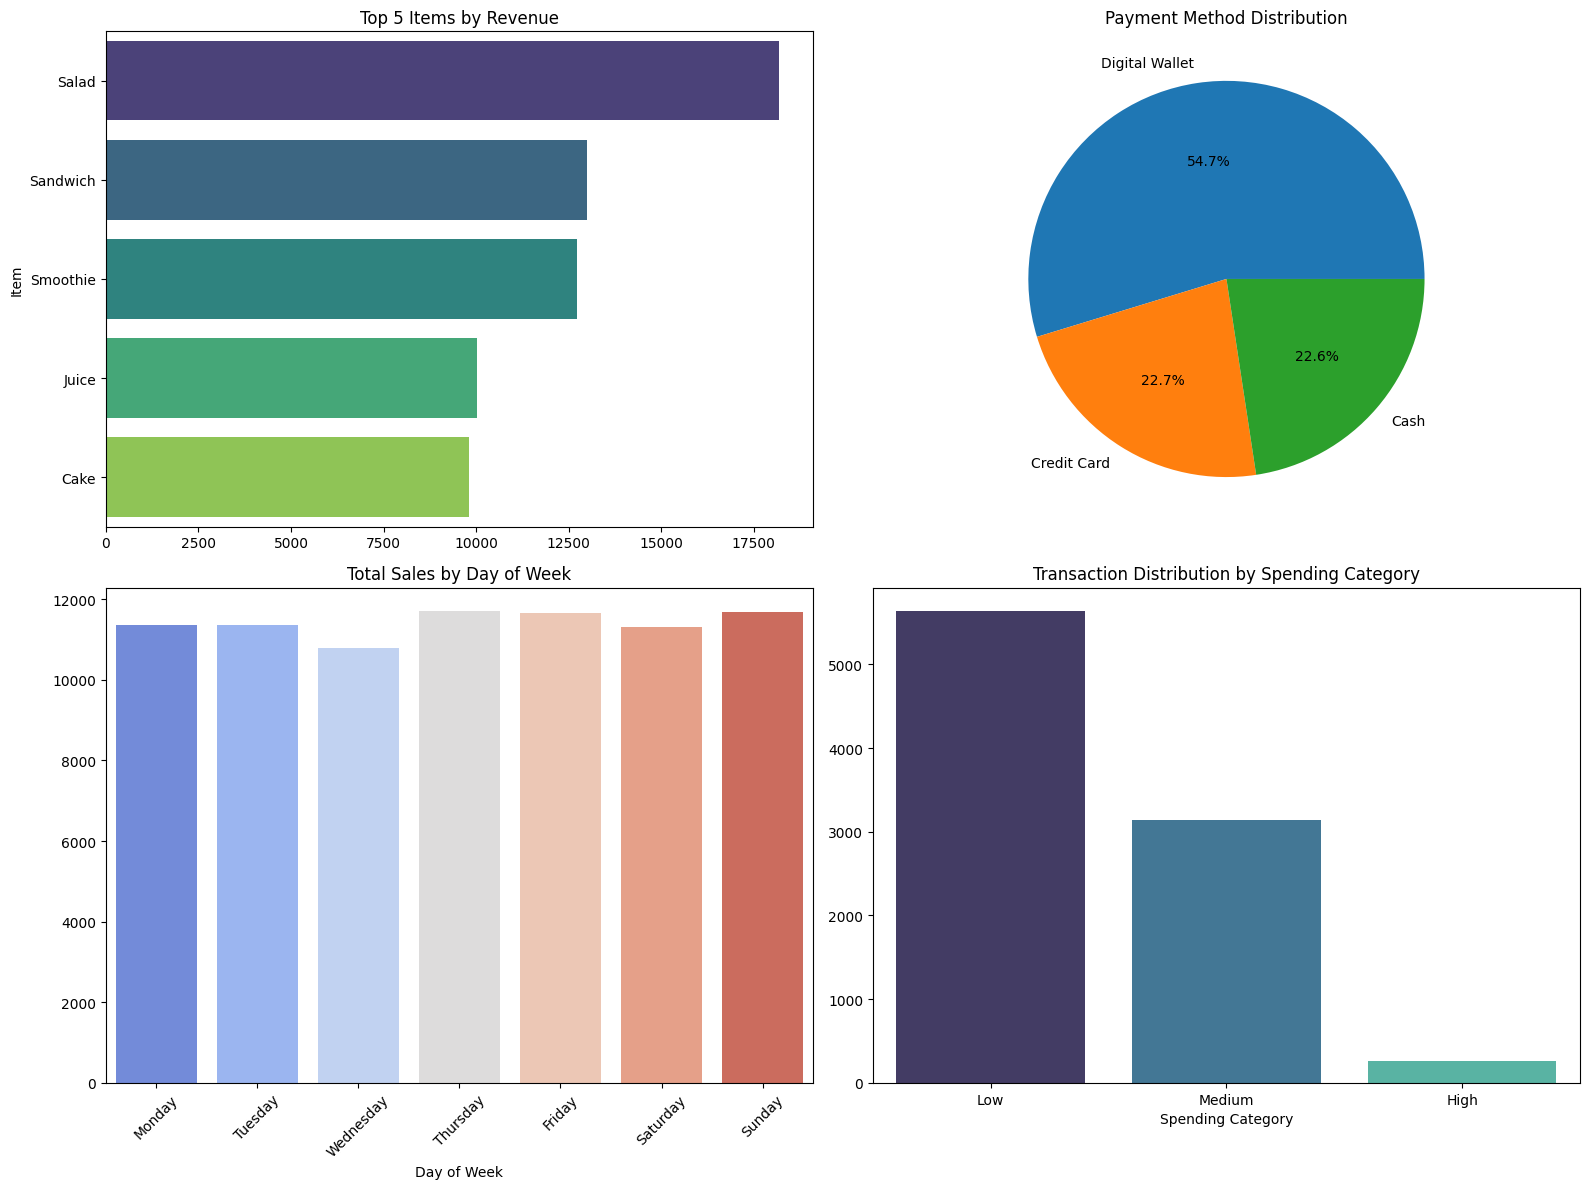

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(x=top_by_revenue.values, y=top_by_revenue.index, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Top 5 Items by Revenue")

payment_counts = df['Payment Method'].value_counts()
axes[0,1].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
axes[0,1].set_title("Payment Method Distribution")

sns.barplot(x=sales_by_day.index, y=sales_by_day.values, ax=axes[1,0], palette="coolwarm")
axes[1,0].set_title("Total Sales by Day of Week")
axes[1,0].tick_params(axis='x', rotation=45)

sns.barplot(x=spending_dist.index, y=spending_dist.values, ax=axes[1,1], palette="mako")
axes[1,1].set_title("Transaction Distribution by Spending Category")

plt.tight_layout()
plt.savefig("summary_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
from google.colab import files

files.download('summary_dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Synthesis: How these findings are interconnected

The four findings above lead to a common thread: **the opportunity for revenue growth in this cafe lies more in increasing the value per transaction (upsell), rather than in increasing visit frequency or targeting specific times/payment methods.**

- Visit frequency is already high and stable (Finding 4: no exploitable time patterns)
- Payment methods and order types have already formed clear patterns with no exploitable correlation (Finding 3)
- The most realistic source of revenue increase is in **shifting the transaction composition** — from high-volume, low-margin items (Coffee, Cookie) towards bundling with higher-value items (Finding 1), and from the Low to Medium segment (Finding 2)

In other words: **this cafe does not have a problem attracting customers — the problem (and opportunity) lies in how much each customer spends each time they visit.**